In [1]:
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np
# Globalny motyw — raz, na początku notebooka
sns.set_theme(style='whitegrid', palette='muted')
# Dataset tips — restauracja, 244 rachunki (znany z W09)
tips = sns.load_dataset('tips')
print(f"Tips dataset: {tips.shape[0]} wierszy × {tips.shape[1]} kolumn")
print(f"Kolumny: {list(tips.columns)}")
tips.head(3)

Tips dataset: 244 wierszy × 7 kolumn
Kolumny: ['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3


### Ćwiczenie 1
Statystyczne wykresy seaborn

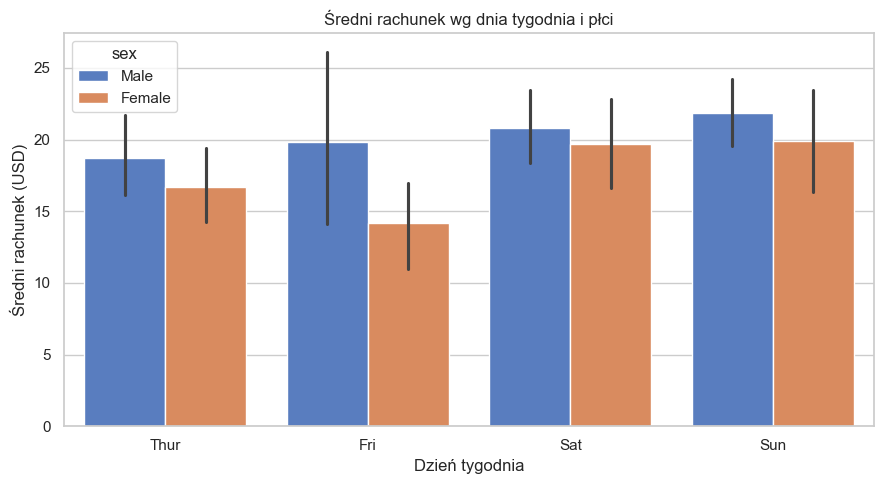

Zapisano: barplot_dzien_plec.png


In [2]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
data=tips,
x='day',
y='total_bill',
hue='sex',
ax=ax,
palette='muted',
errorbar=('ci', 95),       
# 95% CI = przedział ufności średniej
)
ax.set_title('Średni rachunek wg dnia tygodnia i płci')
ax.set_xlabel('Dzień tygodnia')
ax.set_ylabel('Średni rachunek (USD)')
plt.tight_layout()
plt.savefig('barplot_dzien_plec.png', dpi=150, bbox_inches='tight', 
facecolor='white')
plt.show()
plt.close()
print("Zapisano: barplot_dzien_plec.png")

In [4]:
tips.groupby('day',observed=True).size()

day
Thur    62
Fri     19
Sat     87
Sun     76
dtype: int64

Najmniejszą liczbę obserwacji oraz najdłuższe wąsy ma piątek. Im mniej danych tym ciężej podać precyzyjny wynik średniej.

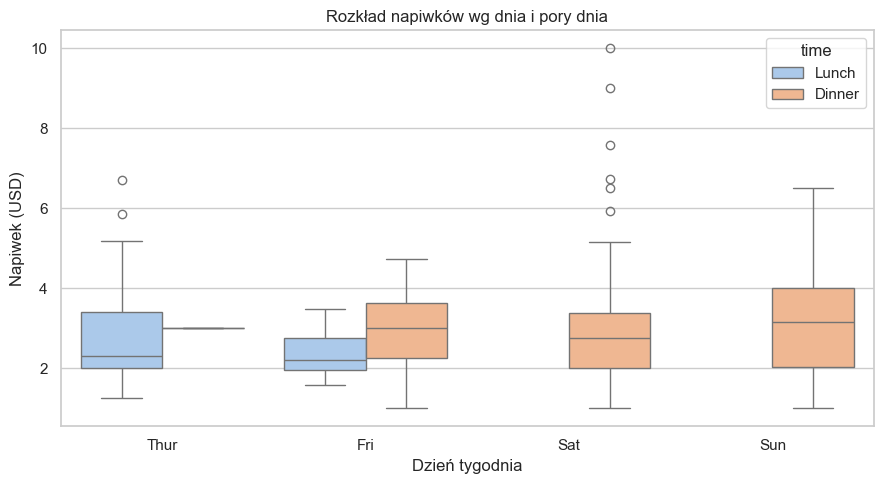

Zapisano: boxplot_napiwki.png


In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(
data=tips,
x='day',                    
y='tip',                    
hue='time',                  
ax=ax,
palette='pastel',
)
ax.set_title('Rozkład napiwków wg dnia i pory dnia')
ax.set_xlabel('Dzień tygodnia')
ax.set_ylabel('Napiwek (USD)')
plt.tight_layout()
plt.savefig('boxplot_napiwki.png', dpi=150, bbox_inches='tight', 
facecolor='white')
plt.show()
plt.close()
print("Zapisano: boxplot_napiwki.png")

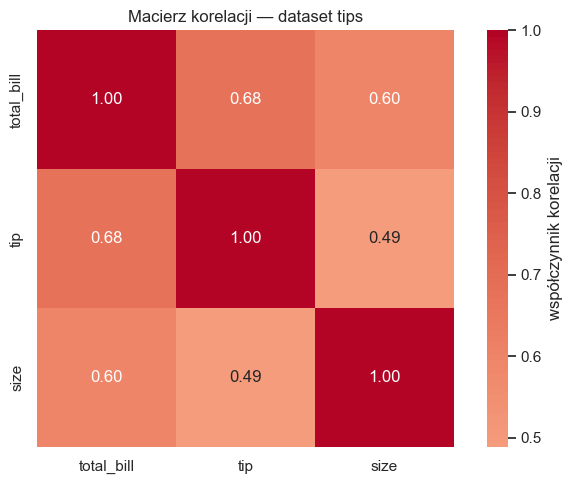

Zapisano: heatmap_korelacja.png


In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
corr = tips.select_dtypes('number').corr()
sns.heatmap(
corr,
annot=True,                
fmt='.2f',                
cmap='coolwarm',                 
center=0,               
ax=ax,
square=True,
cbar_kws={'label': 'współczynnik korelacji'},
)
ax.set_title('Macierz korelacji — dataset tips')
plt.tight_layout()
plt.savefig('heatmap_korelacja.png', dpi=150, bbox_inches='tight', 
facecolor='white')
plt.show()
plt.close()
print("Zapisano: heatmap_korelacja.png")

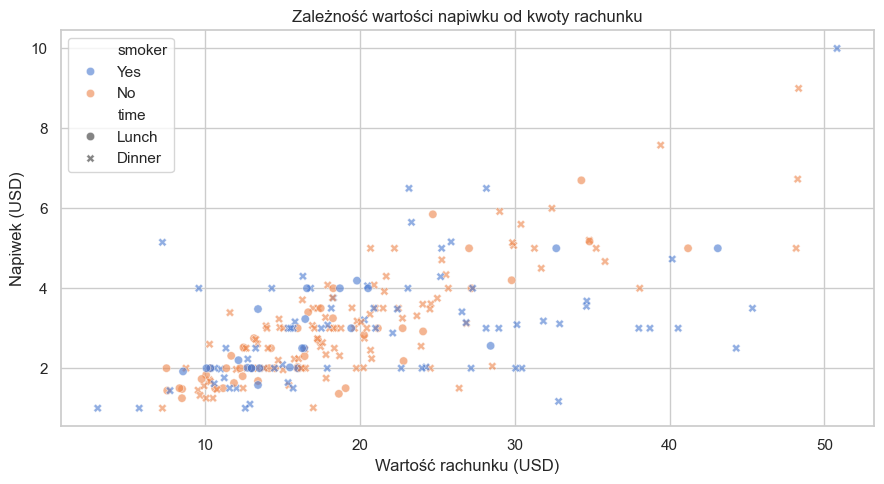

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(
    data=tips,
    x='total_bill',        
    y='tip',               
    hue='smoker',         
    style='time',          
    alpha=0.6,             
    ax=ax
)

ax.set_title('Zależność wartości napiwku od kwoty rachunku')
ax.set_xlabel('Wartość rachunku (USD)')
ax.set_ylabel('Napiwek (USD)')

plt.tight_layout()
plt.savefig('scatter_rachunek_napiwek.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()

### Ćwiczenie 2
Subplots, GridSpec, shared axes

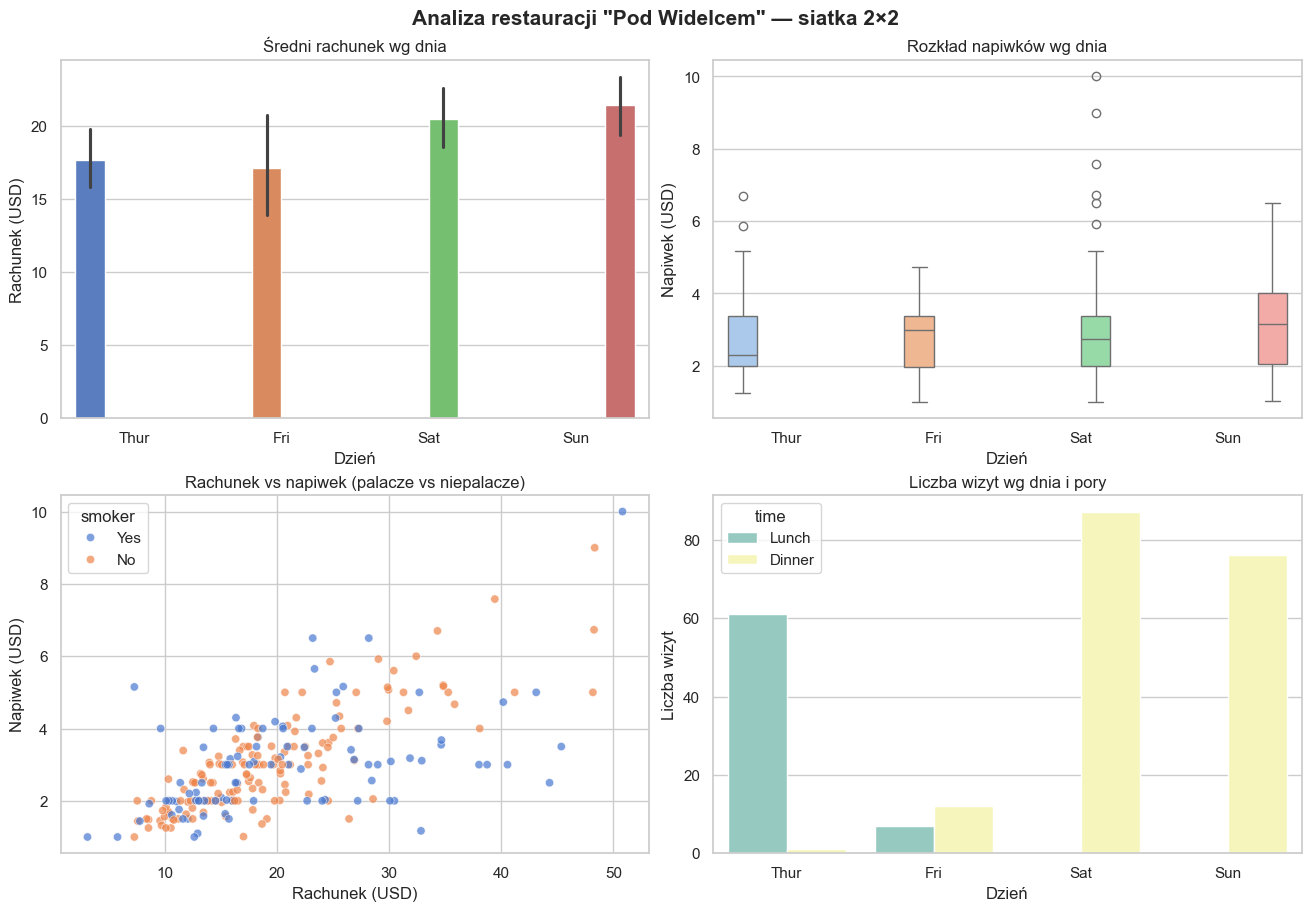

Zapisano: siatka_2x2.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)
sns.barplot(data=tips, x='day', y='total_bill', hue='day', legend=False,
ax=axes[0, 0], palette='muted', errorbar=('ci', 95))
axes[0, 0].set_title('Średni rachunek wg dnia')
axes[0, 0].set_xlabel('Dzień')
axes[0, 0].set_ylabel('Rachunek (USD)')
sns.boxplot(
data=tips,
x='day',                    
y='tip',                    
hue='day', legend=False,
ax=axes[0, 1],
palette='pastel',
)
axes[0, 1].set_title('Rozkład napiwków wg dnia')
axes[0, 1].set_xlabel('Dzień')
axes[0, 1].set_ylabel('Napiwek (USD)')
sns.scatterplot(
data=tips,
x='total_bill',                     
y='tip',                    
hue='smoker',
alpha=0.7,
ax=axes[1, 0],
)
axes[1, 0].set_title('Rachunek vs napiwek (palacze vs niepalacze)')
axes[1, 0].set_xlabel('Rachunek (USD)')
axes[1, 0].set_ylabel('Napiwek (USD)')
sns.countplot(
data=tips,
x='day',                    
hue='time',
ax=axes[1, 1],
palette='Set3',
)
axes[1, 1].set_title('Liczba wizyt wg dnia i pory')
axes[1, 1].set_xlabel('Dzień')
axes[1, 1].set_ylabel('Liczba wizyt')
fig.suptitle('Analiza restauracji "Pod Widelcem" — siatka 2×2',
fontsize=15, fontweight='bold')
plt.savefig('siatka_2x2.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()
print("Zapisano: siatka_2x2.png")

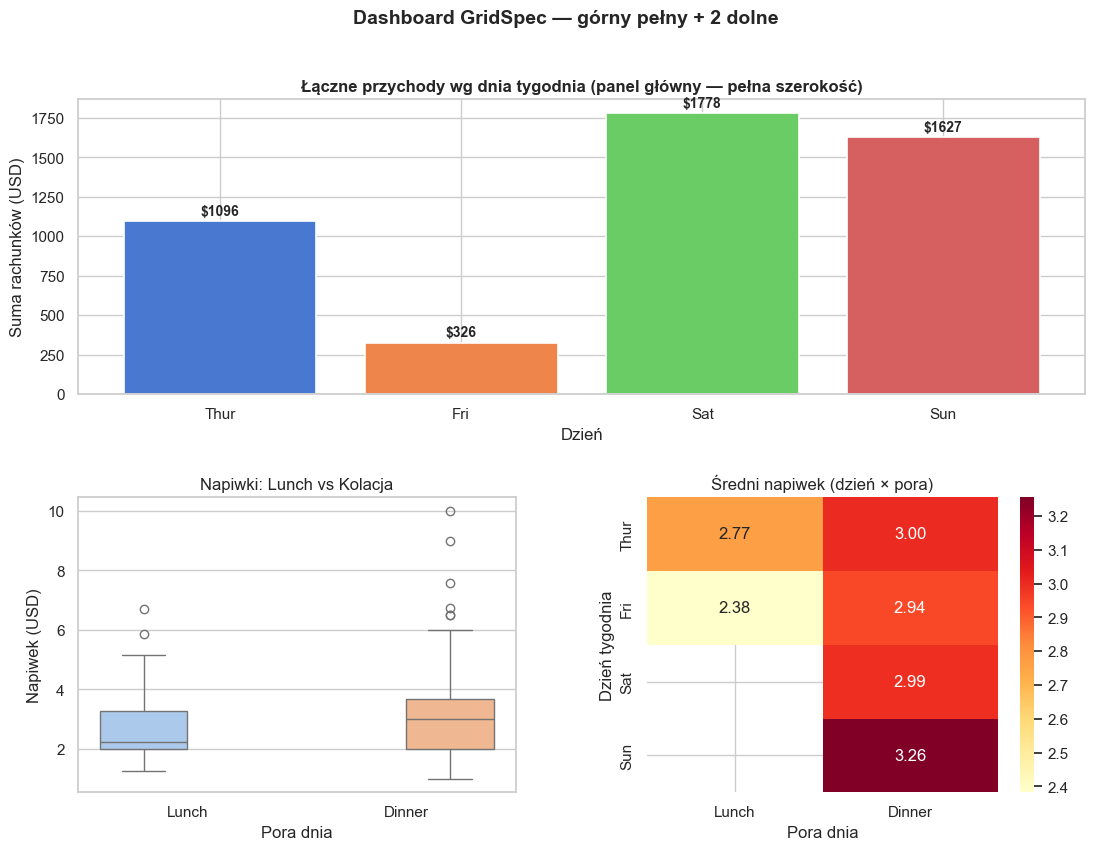

Zapisano: gridspec_dashboard.png


In [9]:
fig = plt.figure(figsize=(13, 9))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

ax_top = fig.add_subplot(gs[0, :])
tips_sum = tips.groupby('day', observed=True)['total_bill'].sum().reset_index()
ax_top.bar(
    tips_sum['day'].astype(str),
    tips_sum['total_bill'],
    color=sns.color_palette('muted')[:4],
    edgecolor='white', linewidth=1.2,
)

for i, val in enumerate(tips_sum['total_bill']):
    ax_top.text(i, val + 20, f'${val:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax_top.set_title('Łączne przychody wg dnia tygodnia (panel główny — pełna szerokość)', fontsize=12, fontweight='bold')
ax_top.set_xlabel('Dzień')
ax_top.set_ylabel('Suma rachunków (USD)')

ax_bl = fig.add_subplot(gs[1, 0])
sns.boxplot(
    data=tips,
    x='time',                    
    y='tip',                     
    hue='time', 
    legend=False,
    ax=ax_bl,
    palette='pastel'
)
ax_bl.set_title('Napiwki: Lunch vs Kolacja')
ax_bl.set_xlabel('Pora dnia')
ax_bl.set_ylabel('Napiwek (USD)')

ax_br = fig.add_subplot(gs[1, 1])

pivot = tips.pivot_table(
    values='tip', 
    index='day', 
    columns='time', 
    aggfunc='mean', 
    observed=True
)

sns.heatmap(
    pivot, 
    annot=True, 
    fmt='.2f', 
    cmap='YlOrRd', 
    ax=ax_br
)

ax_br.set_title('Średni napiwek (dzień × pora)')
ax_br.set_xlabel('Pora dnia')
ax_br.set_ylabel('Dzień tygodnia')

fig.suptitle('Dashboard GridSpec — górny pełny + 2 dolne', fontsize=14, fontweight='bold')
plt.savefig('gridspec_dashboard.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()
print("Zapisano: gridspec_dashboard.png")

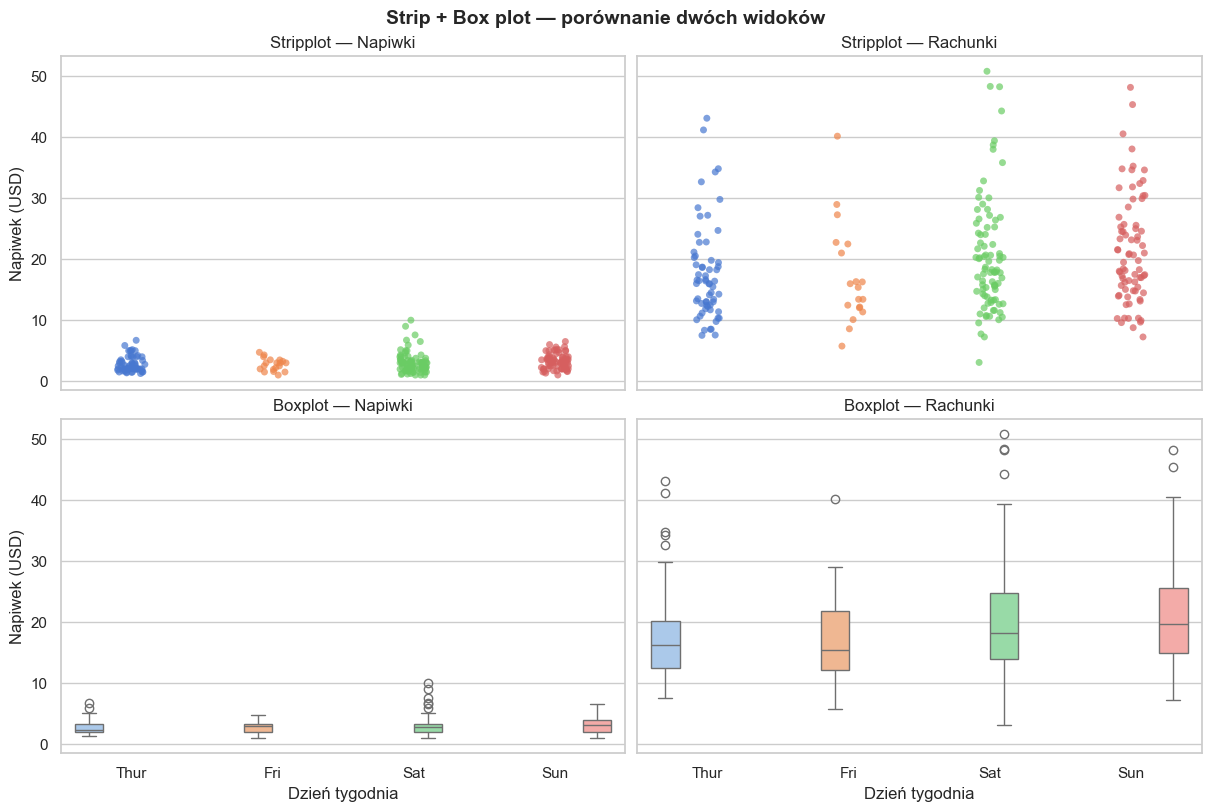

Zapisano: shared_axes.png


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8),
sharex='col', sharey='row',
constrained_layout=True)

sns.stripplot(data=tips, x='day', y='tip', hue='day', legend=False, ax=axes[0, 0], palette='muted', alpha=0.7)
axes[0, 0].set_title('Stripplot — Napiwki')
axes[0, 0].set_ylabel('Napiwek (USD)')

sns.boxplot(data=tips, x='day', y='tip', hue='day', legend=False, ax=axes[1, 0], palette='pastel')
axes[1, 0].set_title('Boxplot — Napiwki')
axes[1, 0].set_xlabel('Dzień tygodnia')
axes[1, 0].set_ylabel('Napiwek (USD)')

sns.stripplot(data=tips, x='day', y='total_bill', hue='day', legend=False, ax=axes[0, 1], palette='muted', alpha=0.7)
axes[0, 1].set_title('Stripplot — Rachunki')
axes[0, 1].set_ylabel('Suma rachunku (USD)')

sns.boxplot(data=tips, x='day', y='total_bill', hue='day', legend=False, ax=axes[1, 1], palette='pastel')
axes[1, 1].set_title('Boxplot — Rachunki')
axes[1, 1].set_xlabel('Dzień tygodnia')
axes[1, 1].set_ylabel('Suma rachunku (USD)')


fig.suptitle('Strip + Box plot — porównanie dwóch widoków',
fontsize=14, fontweight='bold')

plt.savefig('shared_axes.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()
print("Zapisano: shared_axes.png")

### Ćwiczenie 3
Pełny dashboard analityczny

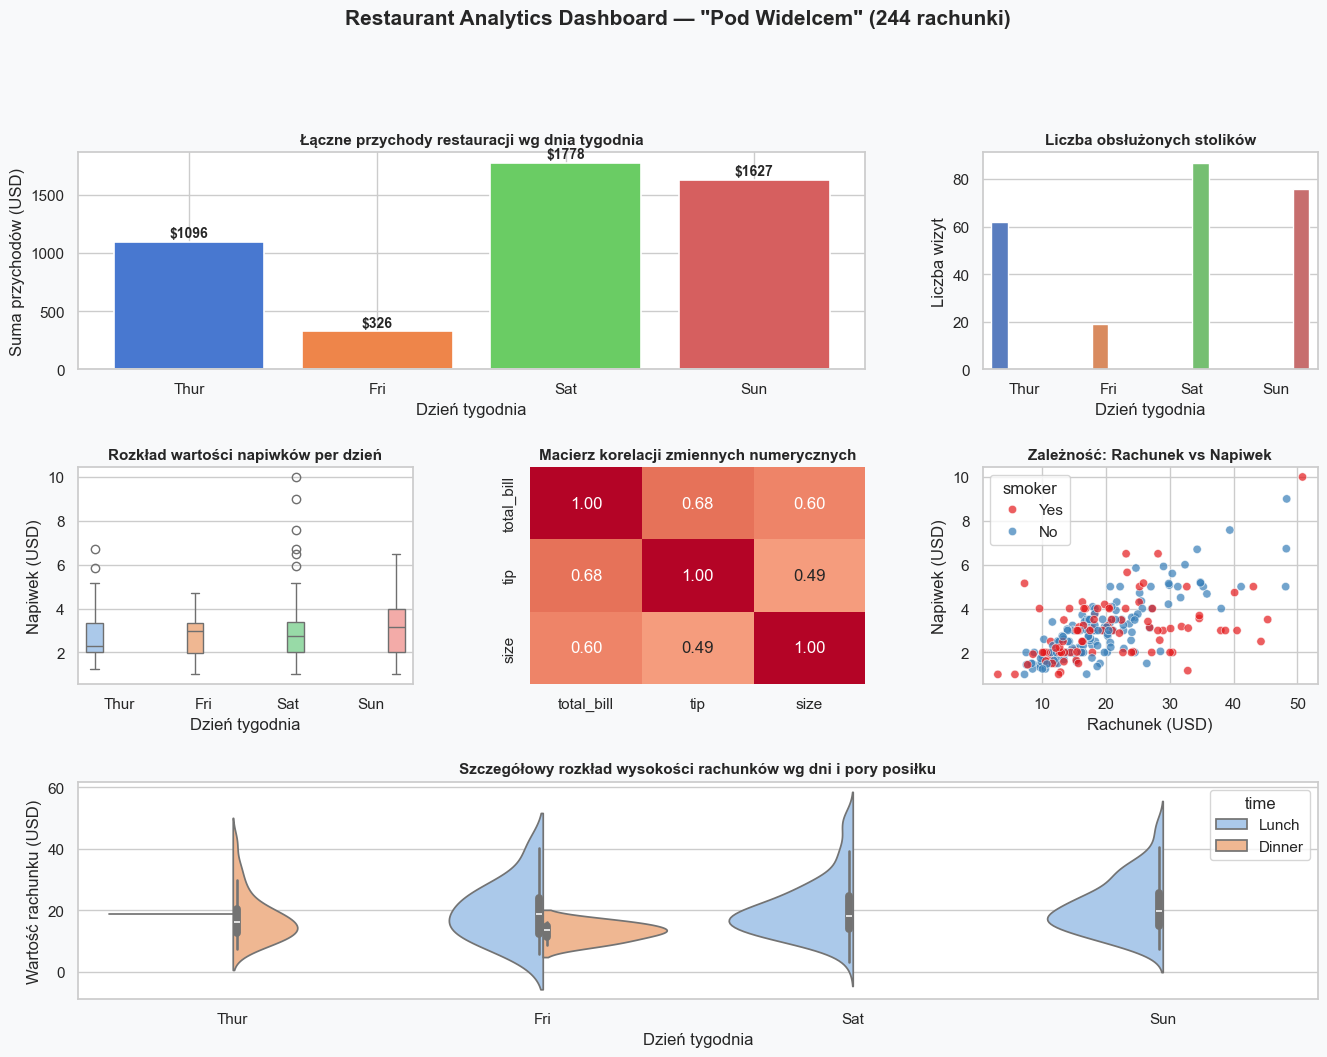

Zapisano: dashboard_pod_widelcem.png


In [13]:
fig = plt.figure(figsize=(16, 11))
fig.patch.set_facecolor('#f8f9fa')   

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, :2])
tips_sum = tips.groupby('day', observed=True)['total_bill'].sum().reset_index()
ax1.bar(
    tips_sum['day'].astype(str),
    tips_sum['total_bill'],
    color=sns.color_palette('muted')[:4],
    edgecolor='white', linewidth=1.2
)

for i, val in enumerate(tips_sum['total_bill']):
    ax1.text(i, val + 15, f'${val:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax1.set_title('Łączne przychody restauracji wg dnia tygodnia', fontsize=11, fontweight='bold')
ax1.set_xlabel('Dzień tygodnia')
ax1.set_ylabel('Suma przychodów (USD)')

ax2 = fig.add_subplot(gs[0, 2])

sns.countplot(
    data=tips, 
    x='day', 
    hue='day',
    legend=False,
    ax=ax2, 
    palette='muted'
)
ax2.set_title('Liczba obsłużonych stolików', fontsize=11, fontweight='bold')
ax2.set_xlabel('Dzień tygodnia')
ax2.set_ylabel('Liczba wizyt')

ax3 = fig.add_subplot(gs[1, 0])
sns.boxplot(
    data=tips, 
    x='day', 
    y='tip', 
    hue='day',
    legend=False,
    ax=ax3, 
    palette='pastel'
)
ax3.set_title('Rozkład wartości napiwków per dzień', fontsize=11, fontweight='bold')
ax3.set_xlabel('Dzień tygodnia')
ax3.set_ylabel('Napiwek (USD)')

ax4 = fig.add_subplot(gs[1, 1])
numeric_cols = tips.select_dtypes(include=['float64', 'int64'])
corr = numeric_cols.corr()

sns.heatmap(
    corr, 
    annot=True, 
    fmt='.2f', 
    cmap='coolwarm', 
    center=0, 
    ax=ax4,
    cbar=False 
)
ax4.set_title('Macierz korelacji zmiennych numerycznych', fontsize=11, fontweight='bold')

ax5 = fig.add_subplot(gs[1, 2])
sns.scatterplot(
    data=tips, 
    x='total_bill', 
    y='tip', 
    hue='smoker', 
    alpha=0.7, 
    ax=ax5,
    palette='Set1'
)
ax5.set_title('Zależność: Rachunek vs Napiwek', fontsize=11, fontweight='bold')
ax5.set_xlabel('Rachunek (USD)')
ax5.set_ylabel('Napiwek (USD)')

ax6 = fig.add_subplot(gs[2, :])
sns.violinplot(
    data=tips, 
    x='day', 
    y='total_bill', 
    hue='time', 
    split=True, 
    ax=ax6, 
    palette='pastel'
)
ax6.set_title('Szczegółowy rozkład wysokości rachunków wg dni i pory posiłku', fontsize=11, fontweight='bold')
ax6.set_xlabel('Dzień tygodnia')
ax6.set_ylabel('Wartość rachunku (USD)')

fig.suptitle('Restaurant Analytics Dashboard — "Pod Widelcem" (244 rachunki)',
fontsize=15, fontweight='bold', y=1.01)

plt.savefig('dashboard_pod_widelcem.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()
print("Zapisano: dashboard_pod_widelcem.png")

### Wnioski biznesowe z dashboardu

1. Najbardziej dochodowy dzień: Sobota, w którą restauracja zarobiła aż $1778.
2. Korelacja rachunek/napiwek: Silna – współczynnik korelacji wynosi 0.68. Oznacza to, że im wyższa kwota na rachunku, tym większy napiwek zostawiają klienci.
3. Palacze vs niepalacze: Z wykresu punktowego wynika, że obie grupy zostawiają podobne napiwki (głównie w przedziale 2-4 dolarów), ale to wśród palaczy padają skrajnie wysokie napiwki (8-10 dolarów)
4. Zalecenia dla właściciela: Wprowadzić promocję na piątkowe popołudnia, aby zachęcić klientów do przybycia, bo to właśnie w tym czasie utarg jest najmniejszy.

### Ćwiczenie 4
Style, adnotacja

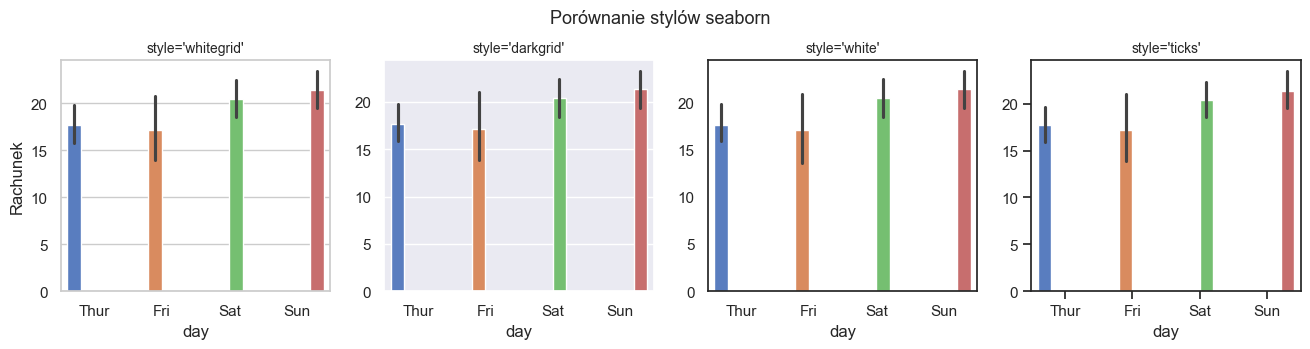

In [ ]:
styles = ['whitegrid', 'darkgrid', 'white', 'ticks']

fig = plt.figure(figsize=(16, 3))

for i, style in enumerate(styles, 1):
    with sns.axes_style(style):
        ax = fig.add_subplot(1, 4, i)
        
        sns.barplot(data=tips, x='day', y='total_bill', hue='day', legend=False,ax=ax, palette='muted'
        )
        
        ax.set_title(f"style='{style}'", fontsize=10)
        ax.set_xlabel('day')
        ax.set_ylabel('Rachunek' if i == 1 else '')

fig.suptitle('Porównanie stylów seaborn', fontsize=13, y=1.05)
plt.savefig('porownanie_stylow.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()

1. Slajdy - 'darkgrid' lub 'whitegrid'. 
Wykresy są wyświetlane na dużych ekranach. Wyraźne linie siatki 
pozwalają szybko i precyzyjnie odczytać wykres.

2. Papier - 'ticks' lub 'white'. 
Artykuły są drukowane często w czerni i bieli. Kolorowe tła marnują 
tusz, wyglądają nieestetycznie na papierze i sprawiają że ciężej odczytać wykres.


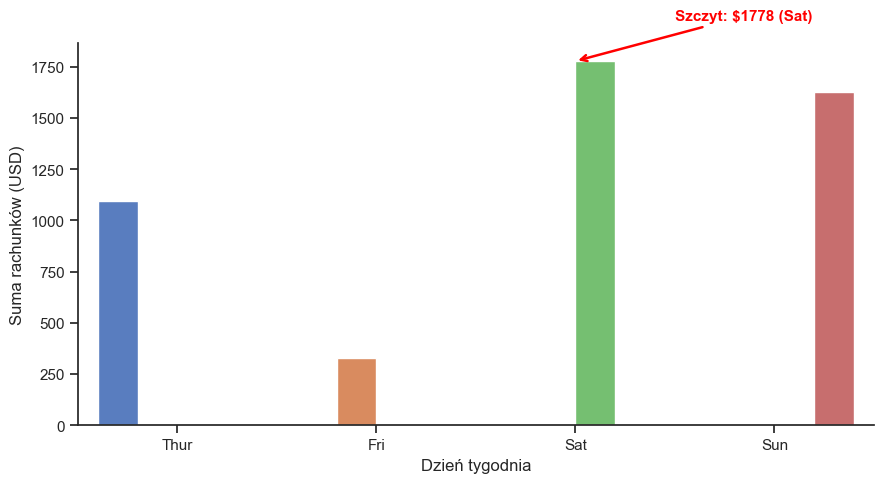

Zapisano: szczyt_przychodow.png


In [20]:
fig, ax = plt.subplots(figsize=(9, 5))
tips_sum = tips.groupby('day', observed=True)['total_bill'].sum().reset_index()
sns.barplot(data=tips_sum, x='day', y='total_bill', hue='day', legend=False,
ax=ax, palette='muted')

max_idx = tips_sum['total_bill'].idxmax()
max_day = tips_sum.loc[max_idx, 'day']
max_val = tips_sum.loc[max_idx, 'total_bill']

ax.annotate(
    f'Szczyt: ${max_val:.0f} ({max_day})',
    xy=(max_idx, max_val),                
    xytext=(max_idx + 0.5, max_val + 200),            
    arrowprops=dict(arrowstyle='->', color='red', lw=1.8),
    fontsize=11, color='red', fontweight='bold'
)

ax.set_xlabel('Dzień tygodnia')
ax.set_ylabel('Suma rachunków (USD)')
sns.despine()                     

plt.tight_layout()
plt.savefig('szczyt_przychodow.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()
print("Zapisano: szczyt_przychodow.png")